In [1]:
suppressPackageStartupMessages({
library(tidyverse)
library(cowplot)
library(sf)
library(geobr)
library(ggvoronoi)
library(paletteer)
library(scico)
library(ggbeeswarm)
theme_set(theme_cowplot())
})
options(repr.plot.width=15, repr.plot.height=9)

# Climate Change in Brazil

data from INMET: https://portal.inmet.gov.br/normais,
downloaded on 2024-08-03

The data comprises of [climate normals](https://en.wikipedia.org/wiki/Climatological_normal), a 30-year monthy temperature average of the periods of 1961-1990, 1981-2010 and 1991-2020.

In [2]:
df <-
    read_tsv('merged.tsv', col_types='') |>
    filter(!is.na(temp), !is.na(Altitude)) |>
    rename(mes=agg) |>
    mutate(mes = factor(mes, levels=c('Janeiro','Fevereiro','Marco','Abril',
                                      'Maio','Junho','Julho','Agosto','Setembro',
                                      'Outubro','Novembro','Dezembro','Ano')))
head(df)

Codigo,Nome.da.Estacao,UF,mes,temp,Latitude,Longitude,Altitude,periodo
<dbl>,<chr>,<chr>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
82704,CRUZEIRO DO SUL,AC,Janeiro,25.3,-7.633333,-72.66667,170,1961-1990
82704,CRUZEIRO DO SUL,AC,Fevereiro,25.1,-7.633333,-72.66667,170,1961-1990
82704,CRUZEIRO DO SUL,AC,Marco,25.1,-7.633333,-72.66667,170,1961-1990
82704,CRUZEIRO DO SUL,AC,Abril,24.9,-7.633333,-72.66667,170,1961-1990
82704,CRUZEIRO DO SUL,AC,Maio,24.7,-7.633333,-72.66667,170,1961-1990
82704,CRUZEIRO DO SUL,AC,Junho,24.0,-7.633333,-72.66667,170,1961-1990


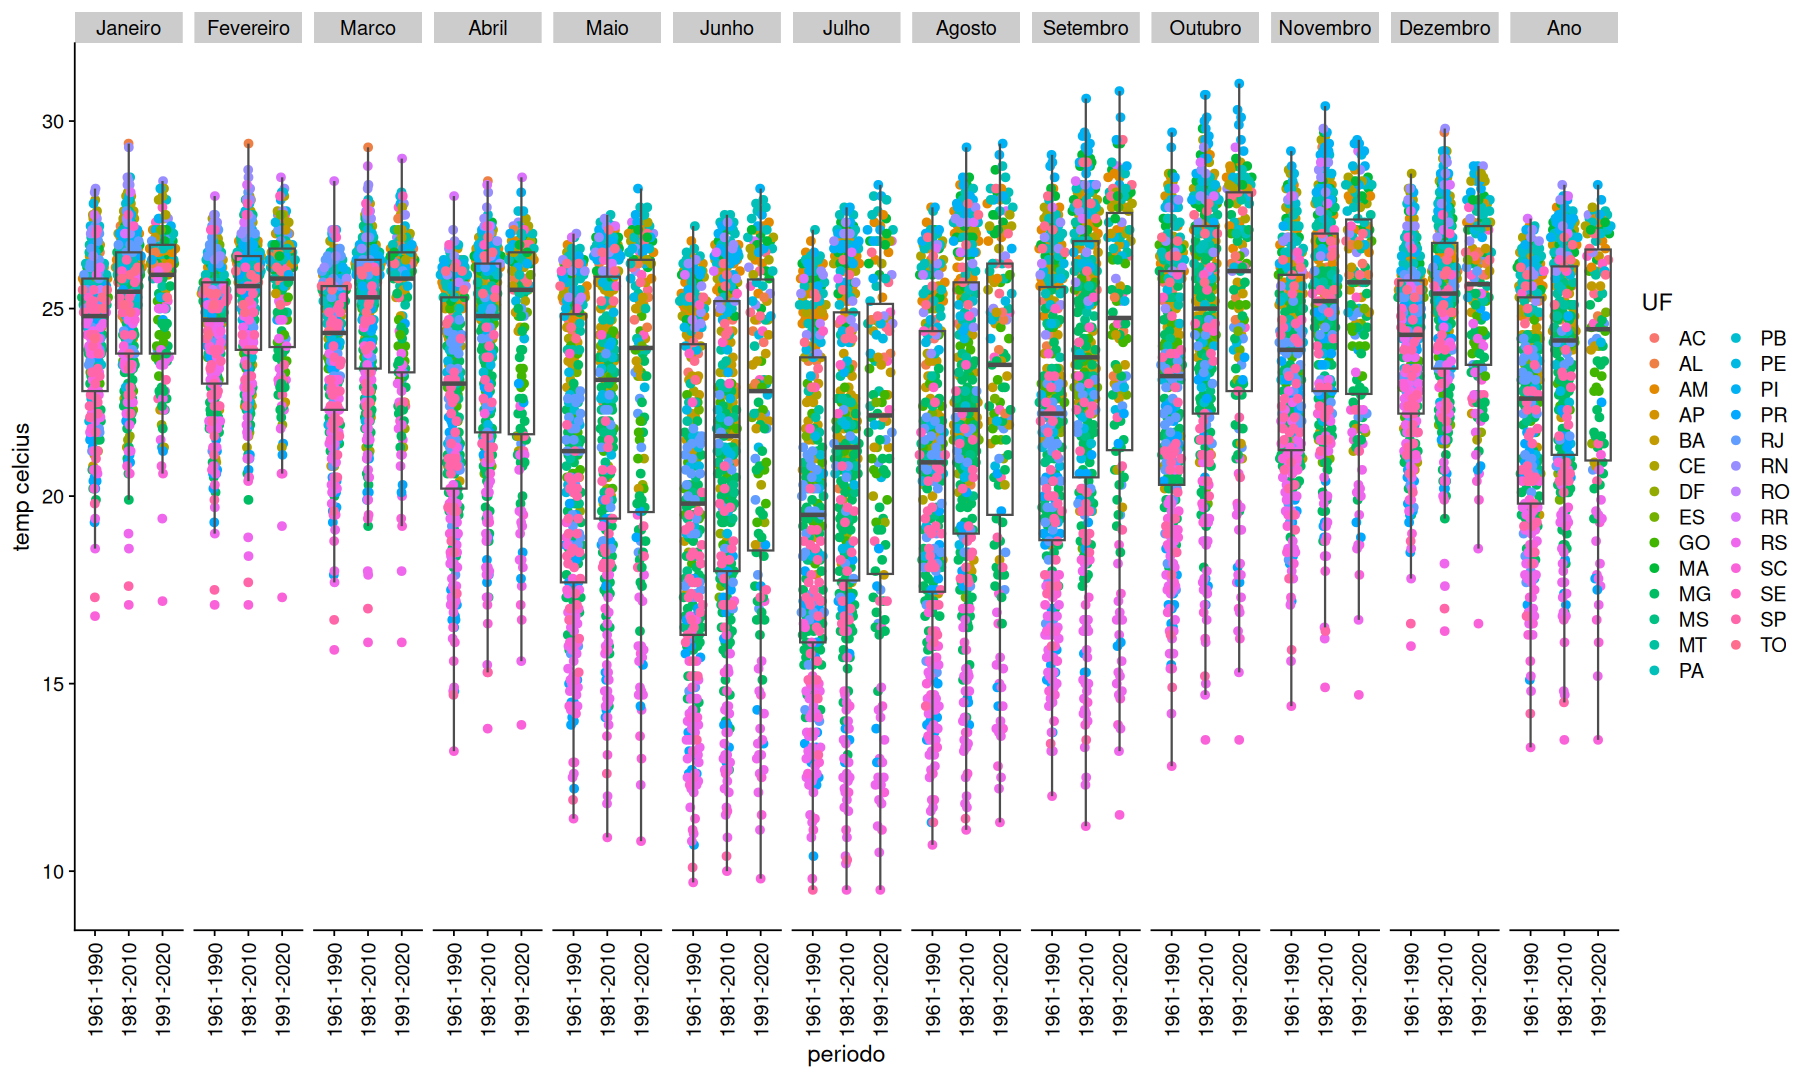

In [3]:
ggplot(df, aes(x=periodo, y=temp, color=UF)) +
geom_quasirandom() +
geom_boxplot(color='gray30',fill=NA, outlier.shape = NA) +
facet_grid(.~mes) +
theme(axis.text.x=element_text(angle=90,vjust=.5)) +
labs(y='temp celcius')

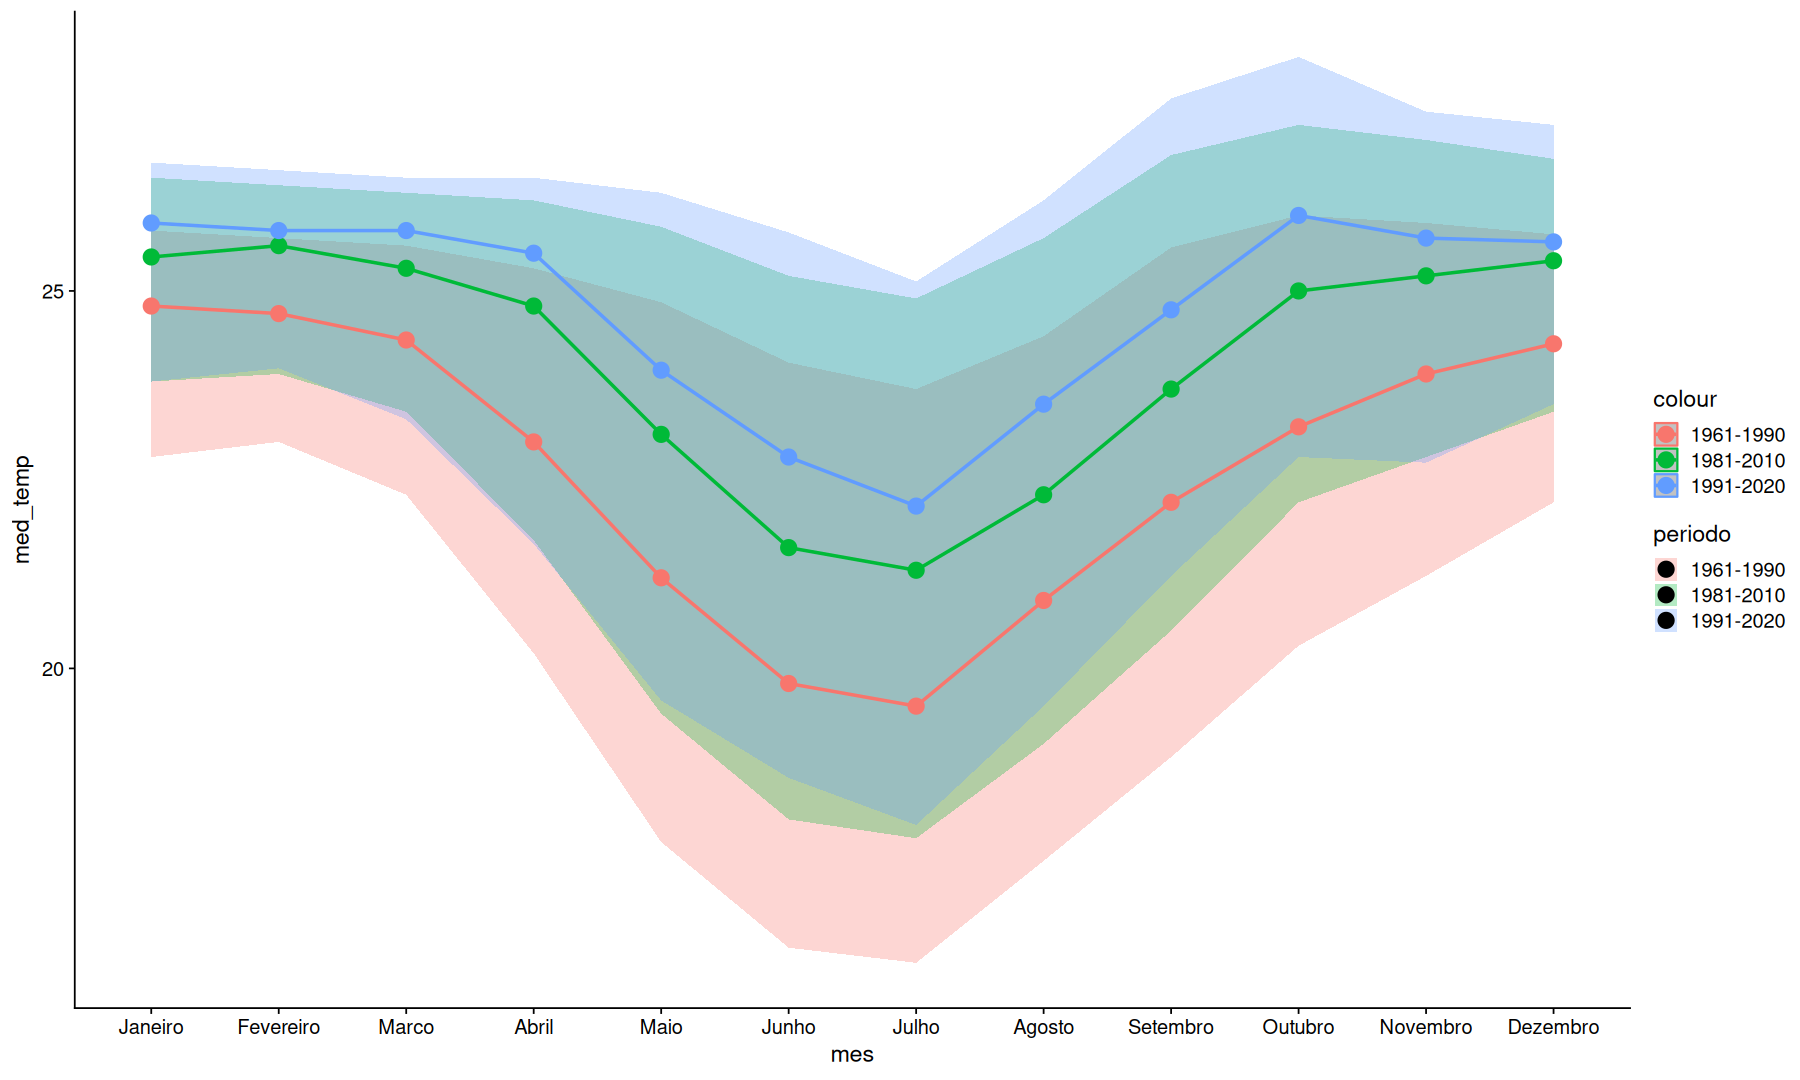

In [4]:
filter(df, mes!='Ano') |>
summarize(
    min_temp = quantile(temp, na.rm=T, p=0.25),
    max_temp = quantile(temp, na.rm=T, p=0.75),
    med_temp = median(temp, na.rm=T),
    .by = c(mes, periodo),
) |>
ggplot(aes(x=mes, y=med_temp, fill=periodo, color=periodo, group=periodo)) +
geom_ribbon(alpha=0.3, aes(color=NULL,ymin=min_temp, ymax=max_temp)) +
geom_line(linewidth=1) +
geom_point(size=4)

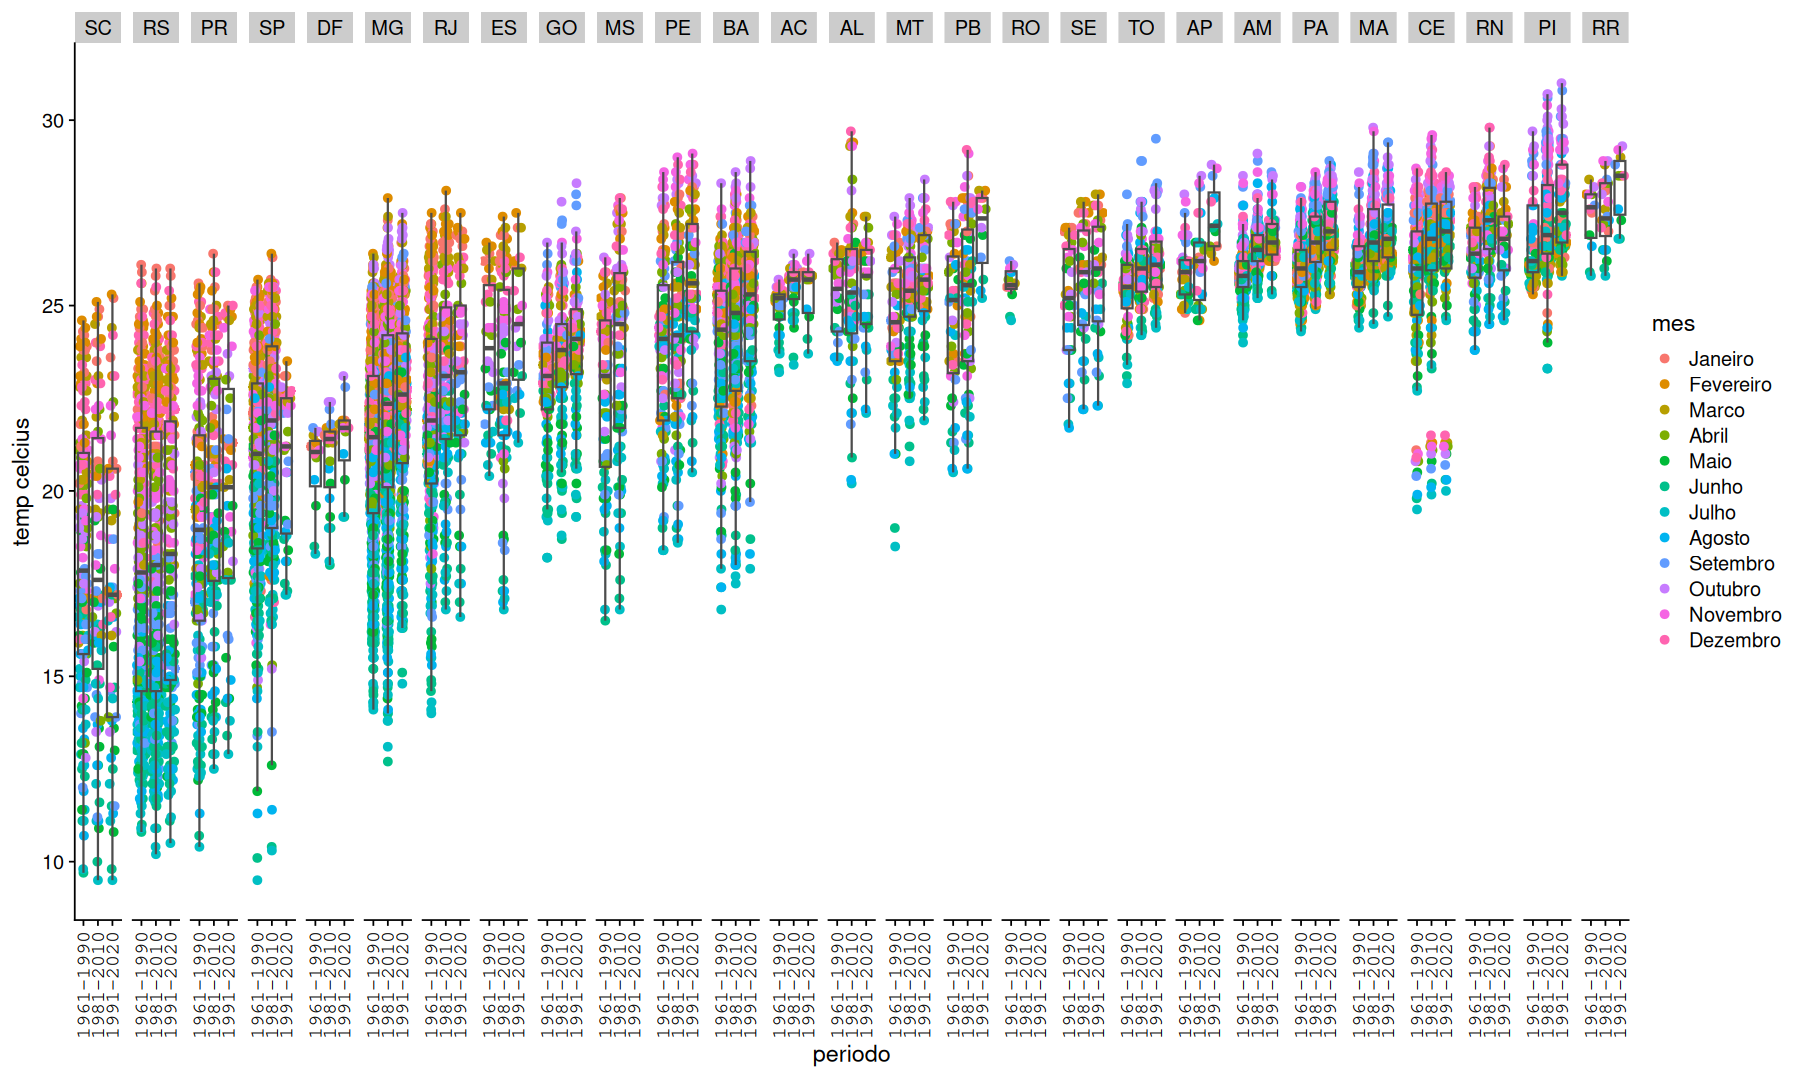

In [5]:
filter(df, mes!='Ano') |>
mutate(UF=fct_reorder(UF, temp)) |>
ggplot(aes(x=fct_reorder(periodo, temp, .na_rm=T), y=temp, color=mes)) +
geom_quasirandom() +
geom_boxplot(color='gray30',fill=NA, outlier.shape = NA) +
facet_grid(.~UF) +
theme(axis.text.x=element_text(angle=90,vjust=.5,family='mono')) +
labs(y='temp celcius',x='periodo')

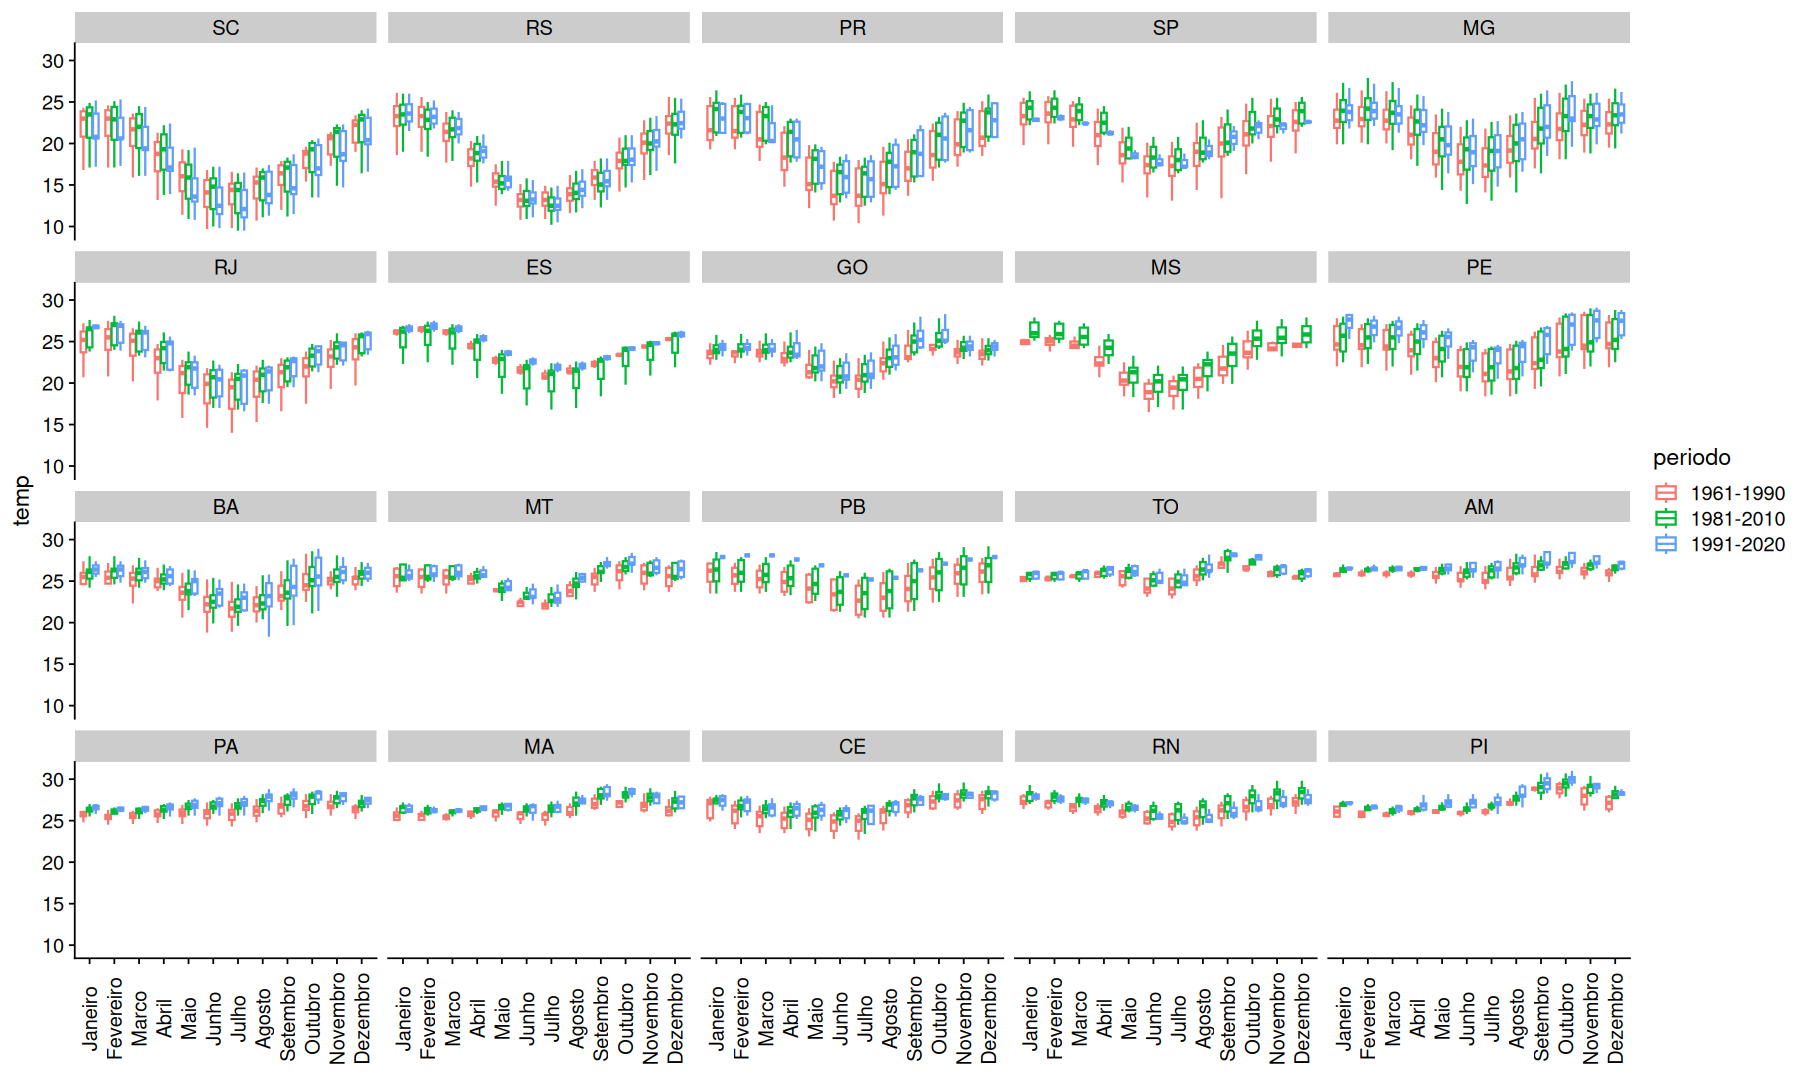

In [6]:
filter(df, mes!='Ano') |>
filter(!(UF %in% c('RO','DF','RR','AP','AC','SE','AL'))) |>
mutate(UF=fct_reorder(UF, temp, .na_rm=T)) |>
ggplot(aes(x=mes, y=temp, color=periodo)) +
geom_boxplot(outlier.shape = NA) +
facet_wrap(~UF) +
labs(x=NULL) +
theme(axis.text.x=element_text(angle=90,vjust=0.5))

In [7]:
states <- read_state(
    year = 2020,
    showProgress = FALSE
)

Using year/date 2020



In [8]:
states_coords <-
    states |>
    st_union() |>
    st_simplify() |>
    st_boundary() |>
    st_coordinates() |>
    as.data.frame() 

state_coords_1 <-
    filter(states_coords, 
        L1 == (
            count(states_coords, L1) |>
            slice_max(n) |>
            pull(L1)
        )
    ) |>
    select(X,Y)

Warning message:
"`fortify(<SpatialPolygonsDataFrame>)` was deprecated in ggplot2 3.4.4.
ℹ Please migrate to sf."


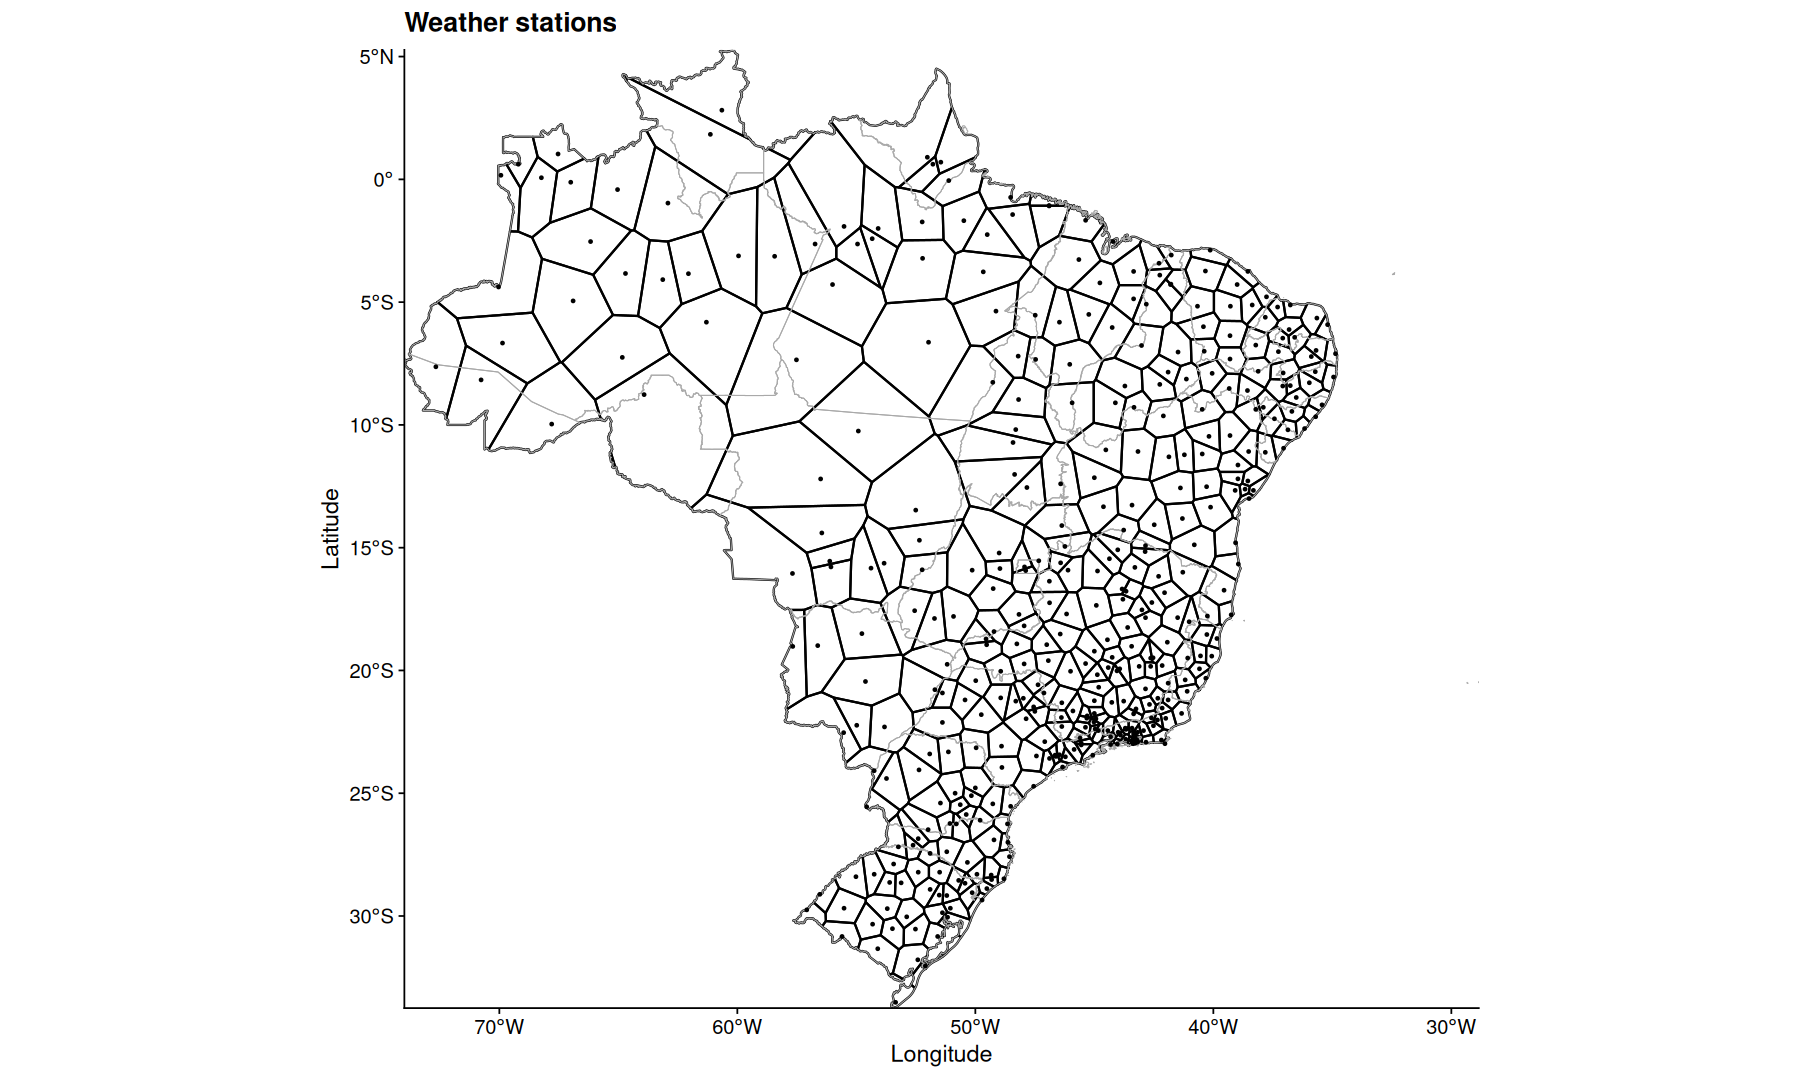

In [9]:
slice_head(df, n=1, by=Codigo) |>
ggplot(aes(x=Longitude, y=Latitude)) +
    stat_voronoi(geom='path', outline = state_coords_1, color='black') +
    geom_sf(aes(x=NULL, y=NULL), fill=NA, color='darkgray', data=states, linewidth=0.3) + 
    geom_point(size=0.5) +
    coord_sf(expand=0) +
    labs(title='Weather stations')

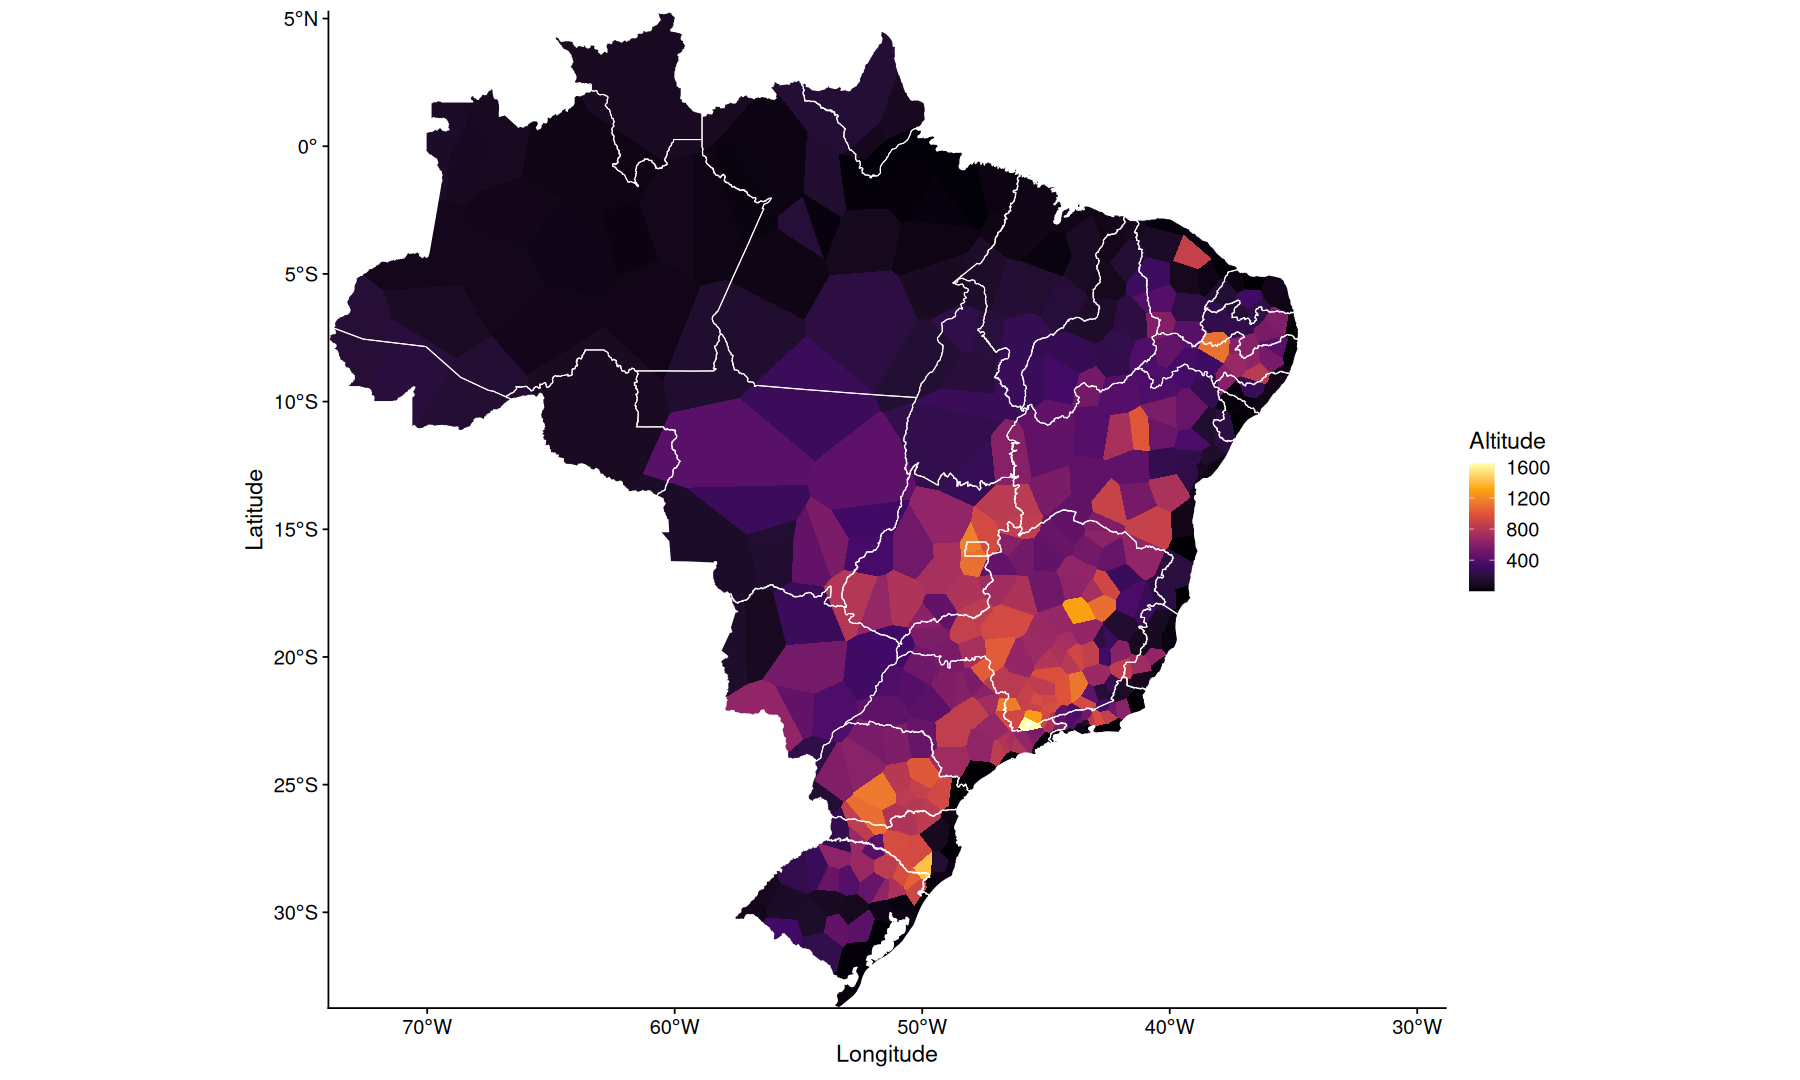

In [10]:
slice_head(df, n=1, by=Codigo) |>
ggplot(aes(x=Longitude, y=Latitude, fill=Altitude)) +
    geom_voronoi(outline = state_coords_1) +
    geom_sf(aes(x=NULL, y=NULL), fill=NA, color='white', data=states, linewidth=0.3) + 
    scale_fill_viridis_c(option='inferno') +
    coord_sf(expand=0)

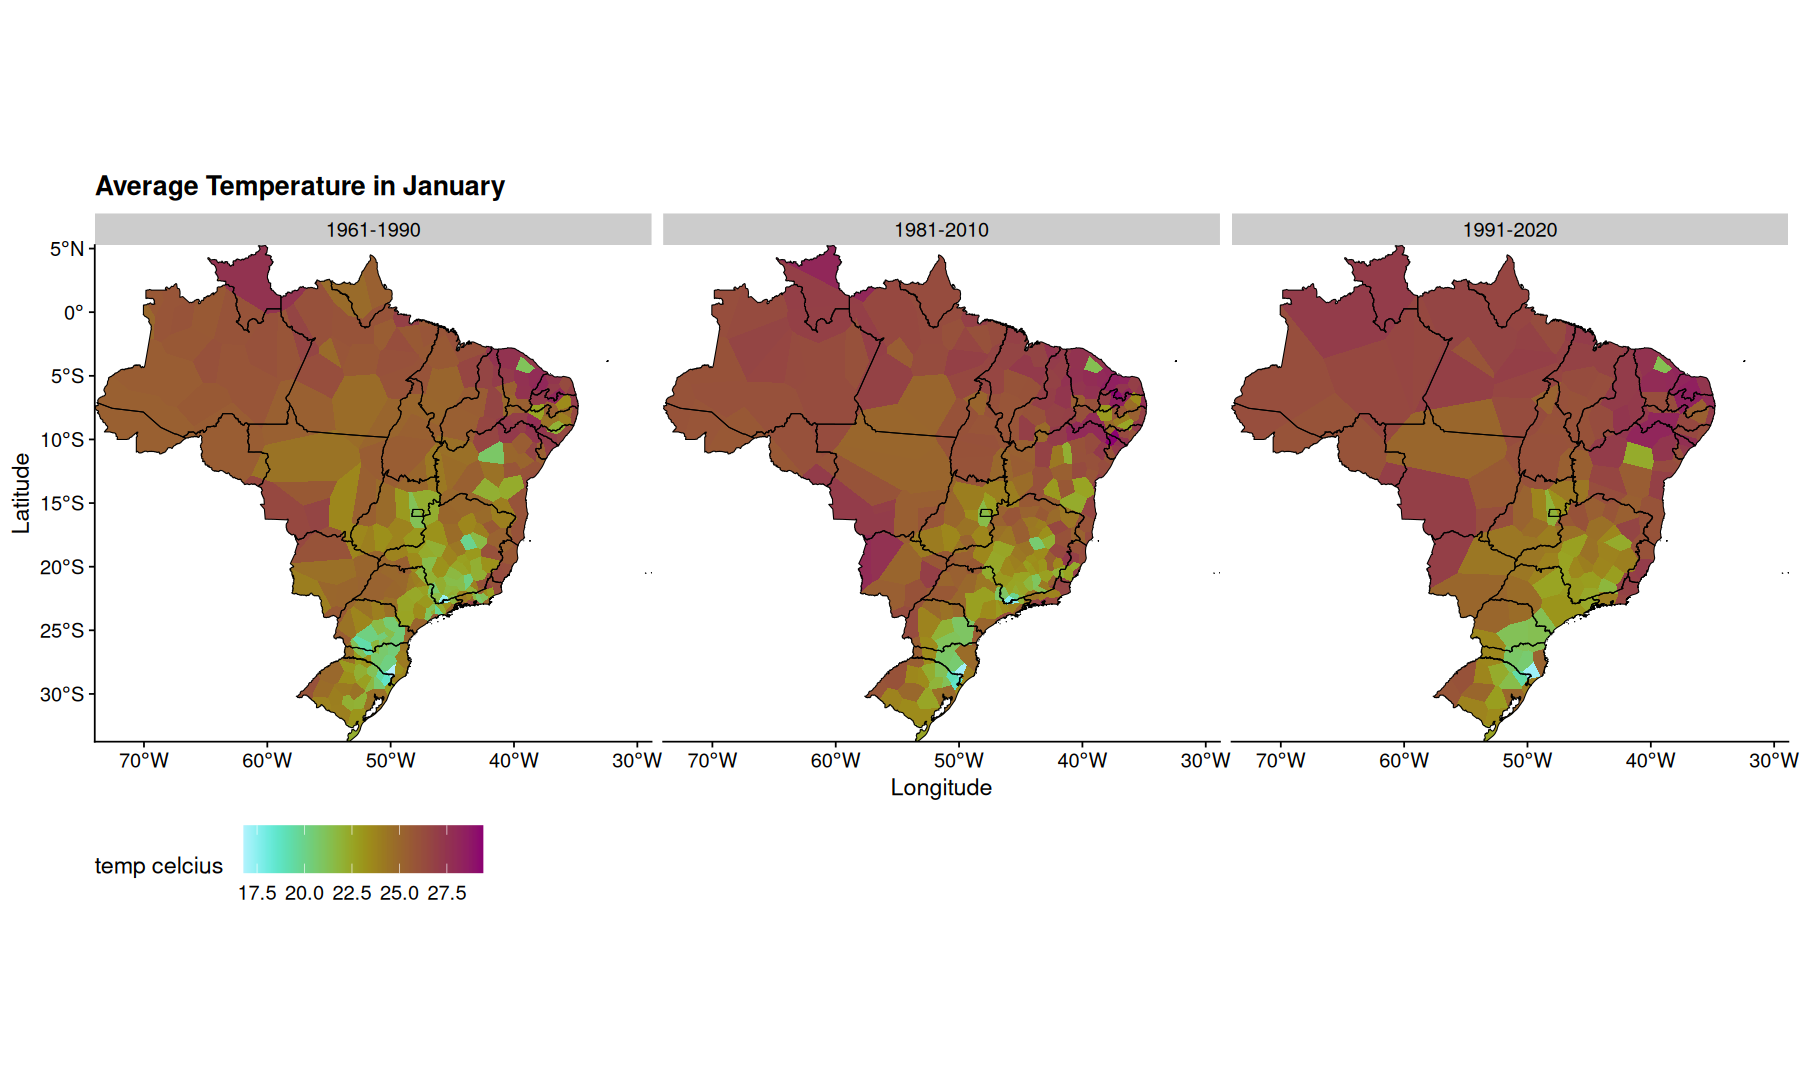

In [11]:
filter(df, mes=='Janeiro', !is.na(temp)) |>
ggplot(aes(x=Longitude, y=Latitude, fill=temp)) +
    geom_voronoi(outline = state_coords_1) +
    geom_sf(aes(x=NULL, y=NULL), fill=NA, color='black', data=states, linewidth=0.3) + 
    scale_fill_scico(palette = 'hawaii', direction = -1) +
    coord_sf(expand=0) +
    facet_wrap(~periodo) +
    theme(legend.position='bottom') +
    theme(legend.key.size = unit(2,"line")) +
    labs(title='Average Temperature in January', fill='temp celcius')

# Temperature vs Altitude

In [12]:
filter(df, mes=='Janeiro') |>
lm(temp ~ Altitude, data=_) -> m1
summary(m1)


Call:
lm(formula = temp ~ Altitude, data = filter(df, mes == "Janeiro"))

Residuals:
    Min      1Q  Median      3Q     Max 
-4.4842 -0.5922  0.1358  0.6923  3.3429 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) 26.8038505  0.0672737  398.43   <2e-16 ***
Altitude    -0.0049851  0.0001264  -39.43   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 1.181 on 736 degrees of freedom
Multiple R-squared:  0.6787,	Adjusted R-squared:  0.6783 
F-statistic:  1555 on 1 and 736 DF,  p-value: < 2.2e-16


In [13]:
# -1 temperature point per 200 Altitude
1/0.0049851

[1] 200.5978

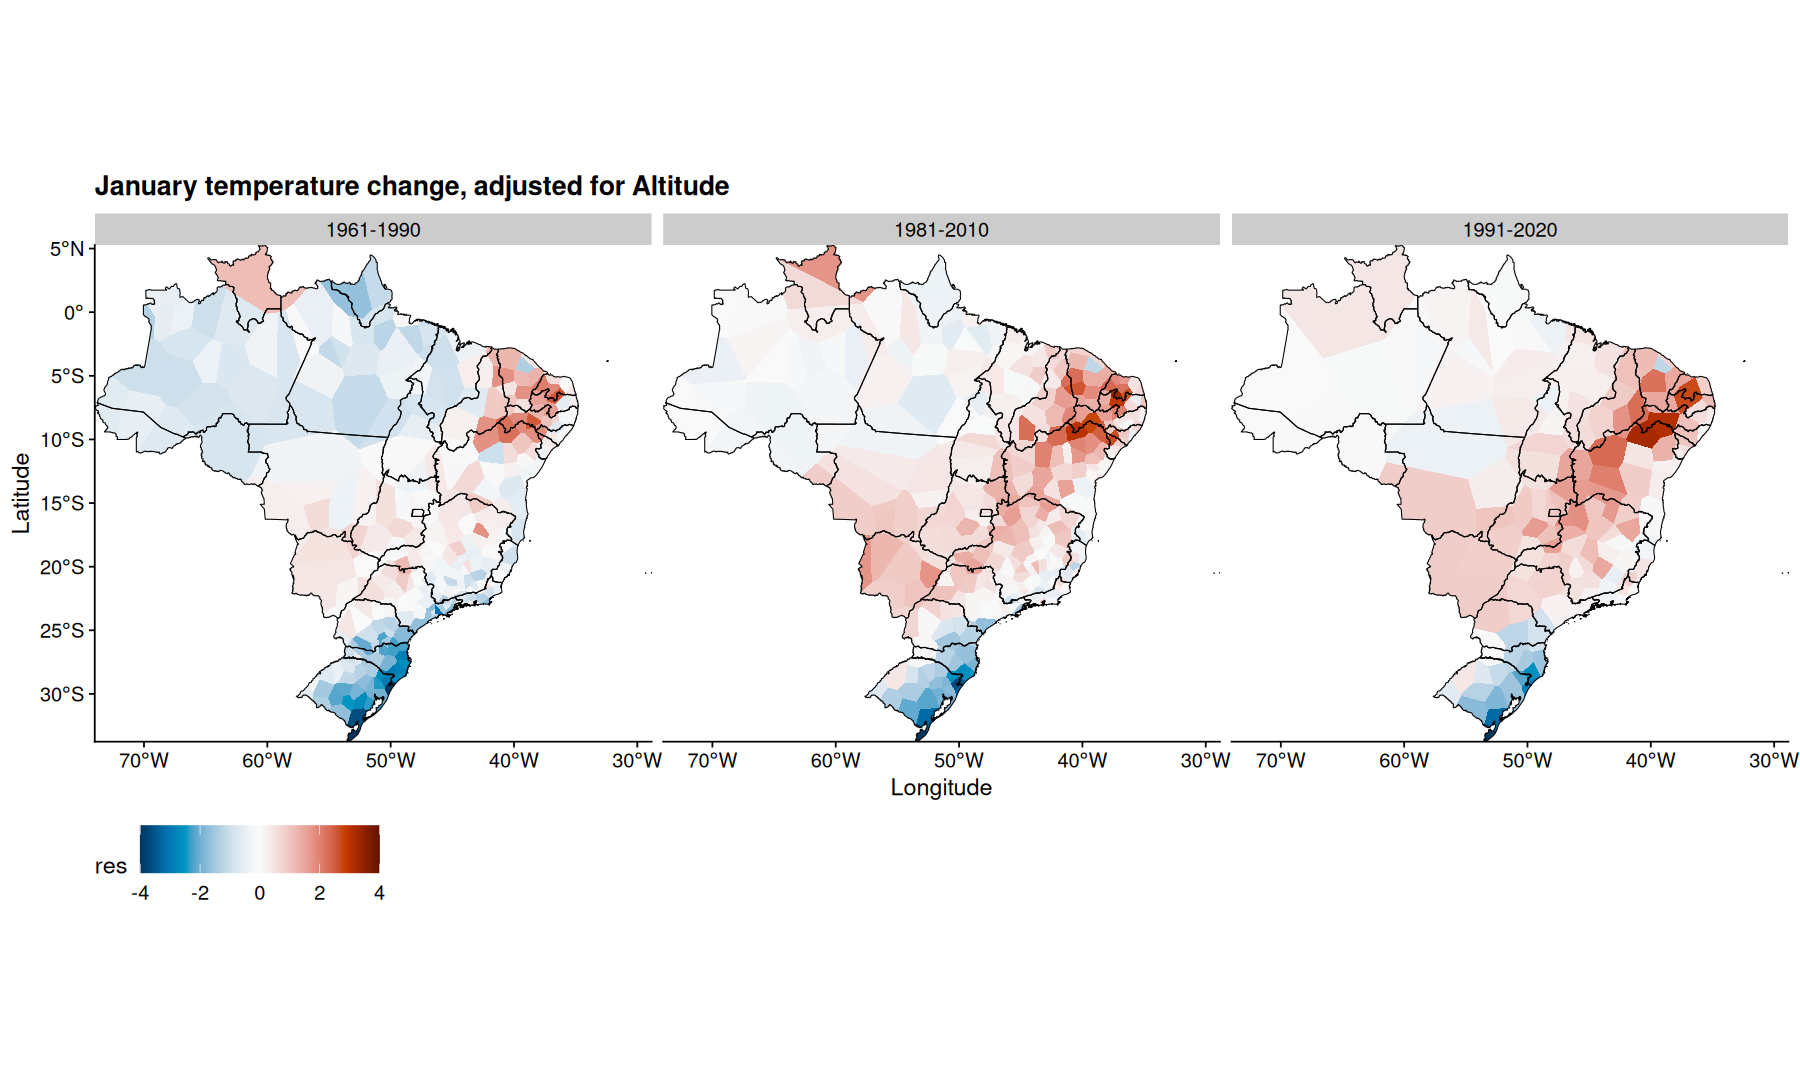

In [14]:
filter(df, mes=='Janeiro') |>
mutate(res = m1$residuals) |>
ggplot(aes(x=Longitude, y=Latitude, fill=res)) +
    geom_voronoi(outline = state_coords_1) +
    geom_sf(aes(x=NULL, y=NULL), fill=NA, color='black', data=states, linewidth=0.3) + 
    scale_fill_paletteer_c(palette='grDevices::RdBu', direction = -1, limits=c(-4, 4), oob=scales::squish) +
    coord_sf(expand=0) +
    facet_wrap(~periodo) +
    theme(legend.position='bottom') +
    labs(title='January temperature change, adjusted for Altitude') +
    theme(legend.key.size = unit(2,"line"))

In [15]:
filter(df, mes=='Janeiro') |>
lm(temp ~ Altitude + Longitude + Latitude, data=_) -> m2
summary(m2)


Call:
lm(formula = temp ~ Altitude + Longitude + Latitude, data = filter(df, 
    mes == "Janeiro"))

Residuals:
     Min       1Q   Median       3Q      Max 
-2.90365 -0.55448 -0.04891  0.62727  2.71339 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) 30.0712899  0.2401458  125.22   <2e-16 ***
Altitude    -0.0043443  0.0001102  -39.43   <2e-16 ***
Longitude    0.0504501  0.0048983   10.30   <2e-16 ***
Latitude     0.0741476  0.0043576   17.02   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.9349 on 734 degrees of freedom
Multiple R-squared:  0.7991,	Adjusted R-squared:  0.7982 
F-statistic: 972.9 on 3 and 734 DF,  p-value: < 2.2e-16


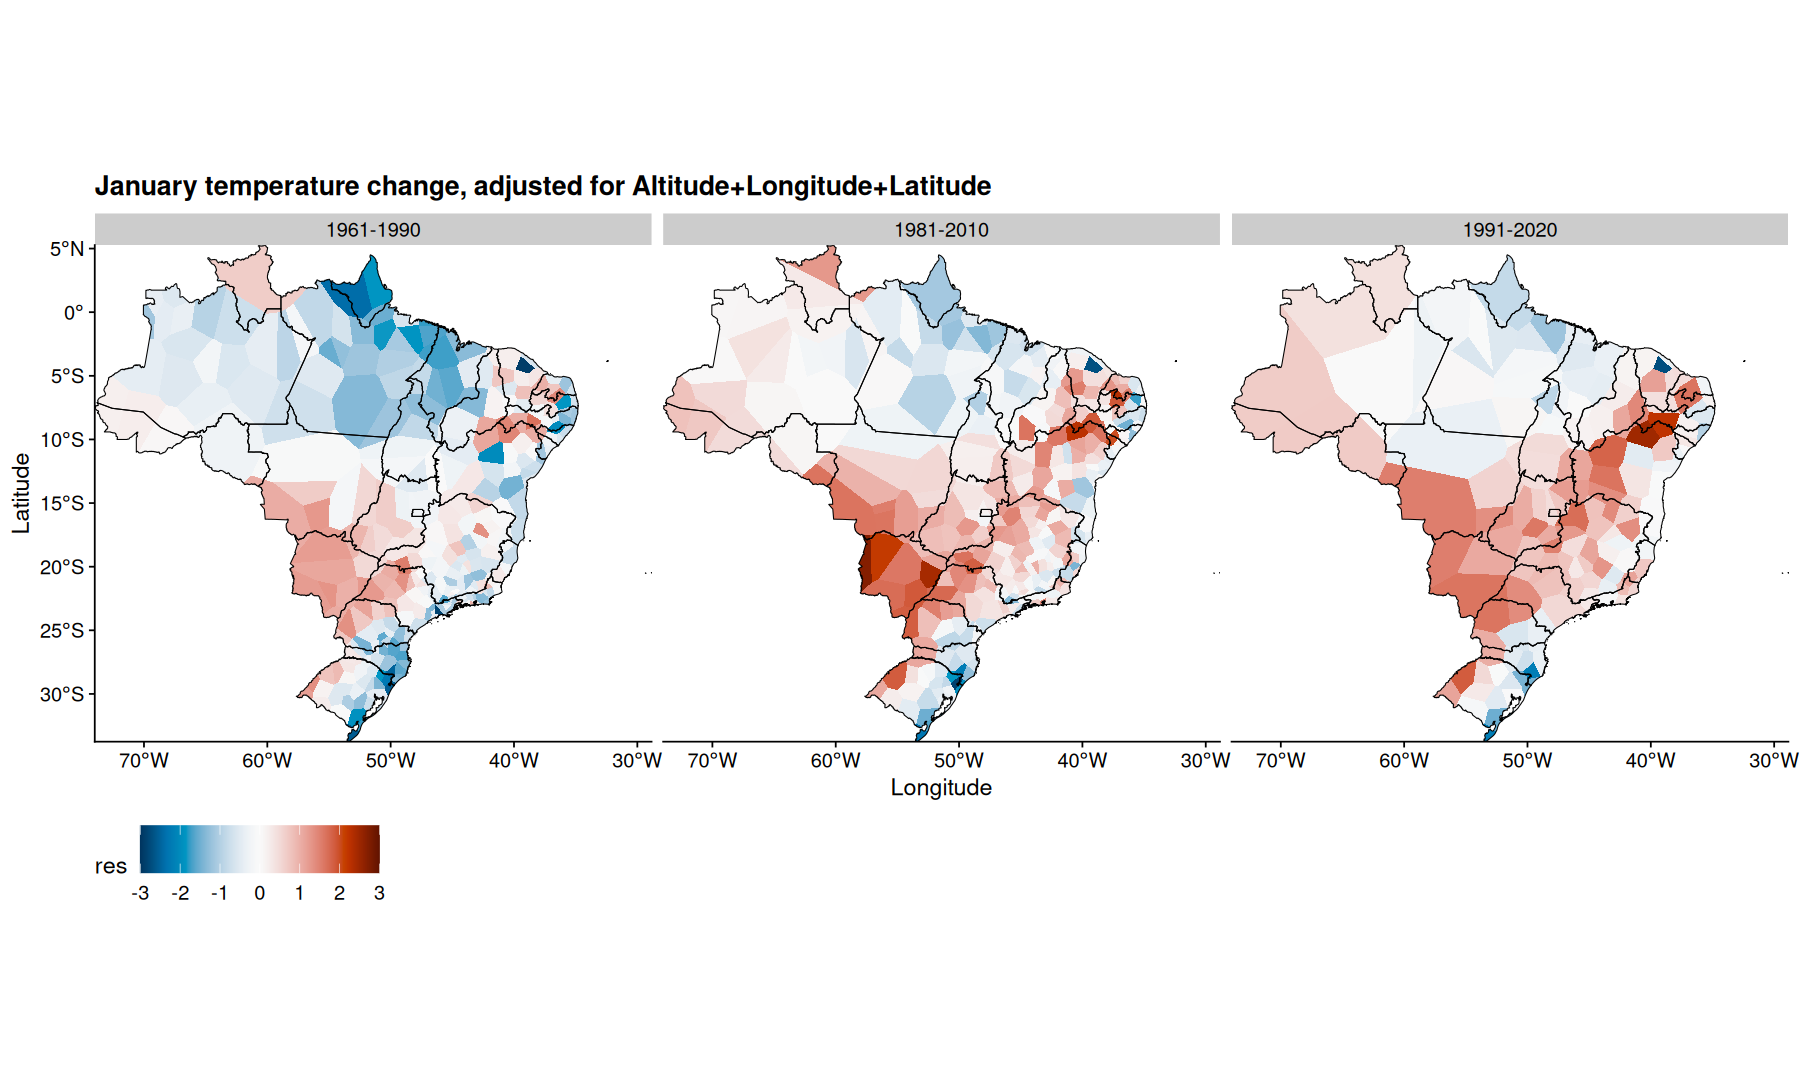

In [16]:
filter(df, mes=='Janeiro') |>
mutate(res = m2$residuals) |>
ggplot(aes(x=Longitude, y=Latitude, fill=res)) +
    geom_voronoi(outline = state_coords_1) +
    geom_sf(aes(x=NULL, y=NULL), fill=NA, color='black', data=states, linewidth=0.3) + 
    scale_fill_paletteer_c(palette='grDevices::RdBu', direction = -1, limits=c(-3, 3), oob=scales::squish) +
    coord_sf(expand=0) +
    facet_wrap(~periodo) +
    theme(legend.position='bottom') +
    labs(title='January temperature change, adjusted for Altitude+Longitude+Latitude') +
    theme(legend.key.size = unit(2,"line"))

In [17]:
filter(df, mes=='Janeiro') |>
lm(temp ~ UF + Altitude + Longitude + Latitude, data=_) -> m3
summary(m3)


Call:
lm(formula = temp ~ UF + Altitude + Longitude + Latitude, data = filter(df, 
    mes == "Janeiro"))

Residuals:
     Min       1Q   Median       3Q      Max 
-2.53425 -0.44375 -0.00074  0.47207  1.91739 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 20.359912   1.029470  19.777  < 2e-16 ***
UFAL         4.669301   0.600367   7.777 2.62e-14 ***
UFAM        -0.256167   0.324327  -0.790  0.42988    
UFAP         0.181087   0.518513   0.349  0.72701    
UFBA         4.670519   0.514136   9.084  < 2e-16 ***
UFCE         4.157320   0.532656   7.805 2.14e-14 ***
UFDF         4.346347   0.580237   7.491 2.05e-13 ***
UFES         4.744603   0.577723   8.213 1.03e-15 ***
UFGO         4.503830   0.450074  10.007  < 2e-16 ***
UFMA         2.529512   0.466128   5.427 7.89e-08 ***
UFMG         4.962694   0.499729   9.931  < 2e-16 ***
UFMS         4.534043   0.457622   9.908  < 2e-16 ***
UFMT         3.067743   0.400213   7.665 5.90e-14 ***
UFPA         1.168

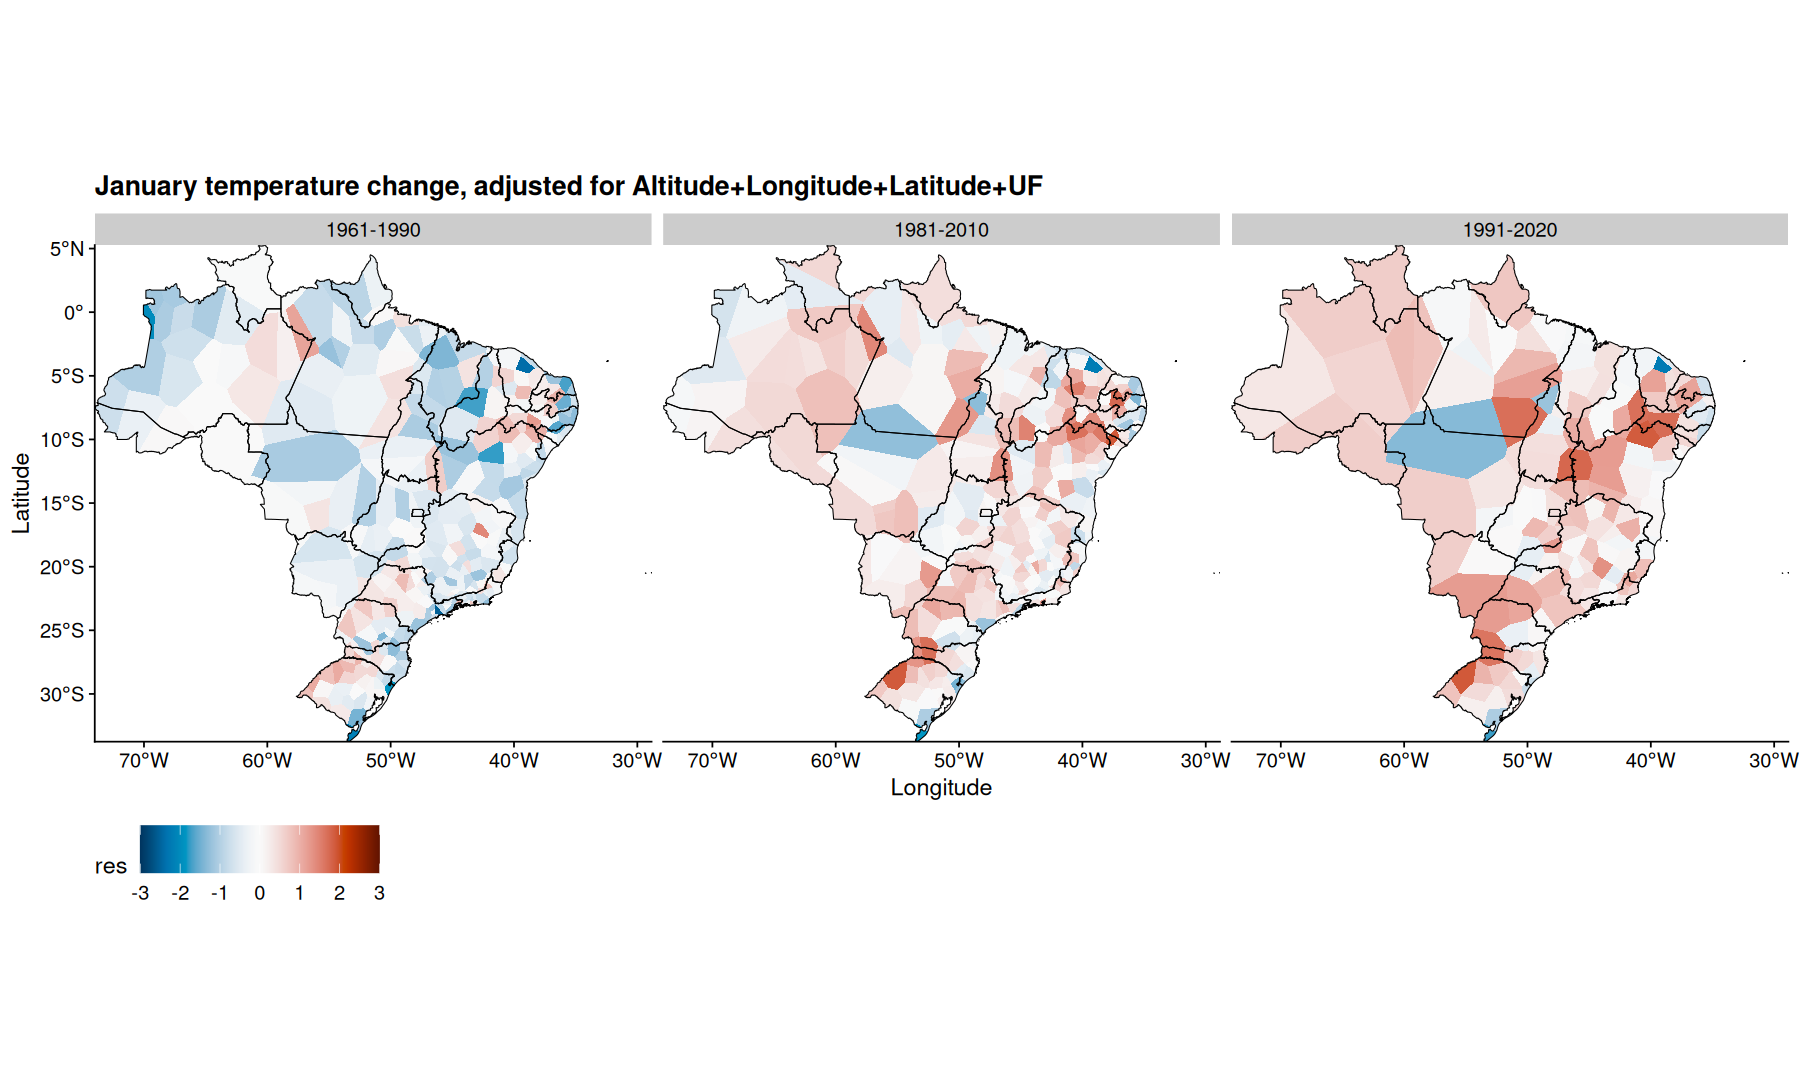

In [18]:
filter(df, mes=='Janeiro') |>
mutate(res = m3$residuals) |>
ggplot(aes(x=Longitude, y=Latitude, fill=res)) +
    geom_voronoi(outline = state_coords_1) +
    geom_sf(aes(x=NULL, y=NULL), fill=NA, color='black', data=states, linewidth=0.3) + 
    scale_fill_paletteer_c(palette='grDevices::RdBu', direction = -1, limits=c(-3, 3), oob=scales::squish) +
    coord_sf(expand=0) +
    facet_wrap(~periodo) +
    theme(legend.position='bottom') +
    labs(title='January temperature change, adjusted for Altitude+Longitude+Latitude+UF') +
    theme(legend.key.size = unit(2,"line"))

In [19]:
filter(df, mes=='Ano') |>
lm(temp ~ UF + Altitude + Longitude + Latitude, data=_) -> m4
summary(m4)


Call:
lm(formula = temp ~ UF + Altitude + Longitude + Latitude, data = filter(df, 
    mes == "Ano"))

Residuals:
     Min       1Q   Median       3Q      Max 
-2.87835 -0.57859 -0.00098  0.60844  3.05717 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) 20.5151139  1.3097334  15.664  < 2e-16 ***
UFAL         4.1351596  0.7752313   5.334 1.31e-07 ***
UFAM        -0.3251572  0.4248844  -0.765 0.444371    
UFAP         0.3029129  0.6611421   0.458 0.646981    
UFBA         4.5265385  0.6660147   6.796 2.37e-11 ***
UFCE         3.8892245  0.6883239   5.650 2.37e-08 ***
UFDF         5.1397953  0.7391640   6.954 8.46e-12 ***
UFES         4.7171152  0.7416989   6.360 3.73e-10 ***
UFGO         5.5363202  0.5851868   9.461  < 2e-16 ***
UFMA         3.1349333  0.6047224   5.184 2.88e-07 ***
UFMG         5.1089479  0.6465612   7.902 1.13e-14 ***
UFMS         4.4115166  0.5912692   7.461 2.66e-13 ***
UFMT         3.7196637  0.5214658   7.133 2.55e-12 ***
UFPA    

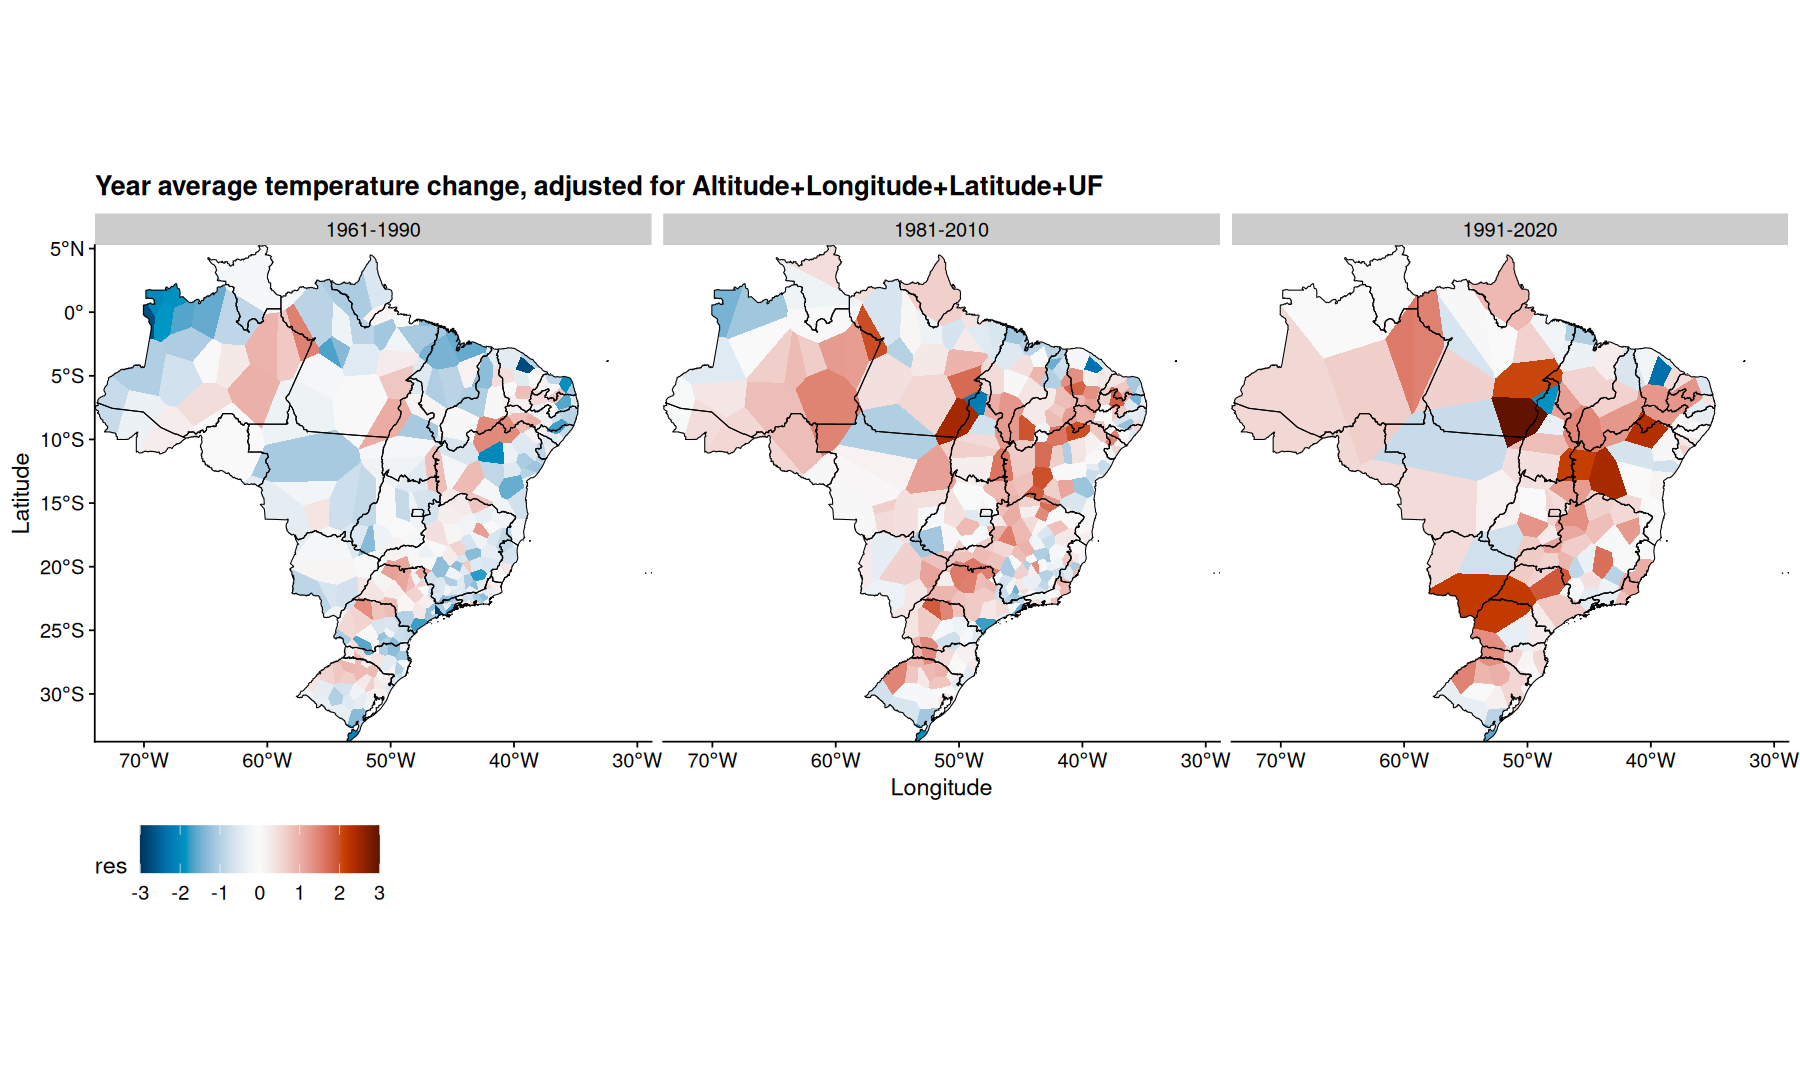

In [20]:
filter(df, mes=='Ano') |>
mutate(res = m4$residuals) |>
ggplot(aes(x=Longitude, y=Latitude, fill=res)) +
    geom_voronoi(outline = state_coords_1) +
    geom_sf(aes(x=NULL, y=NULL), fill=NA, color='black', data=states, linewidth=0.3) + 
    scale_fill_paletteer_c(palette='grDevices::RdBu', direction = -1, limits=c(-3, 3), oob=scales::squish) +
    coord_sf(expand=0) +
    facet_wrap(~periodo) +
    theme(legend.position='bottom') +
    labs(title='Year average temperature change, adjusted for Altitude+Longitude+Latitude+UF') +
    theme(legend.key.size = unit(2,"line"))

# delta temperature

In [21]:
filter(df, mes=='Ano') |>
pivot_wider(names_prefix='p', names_from = periodo, values_from = temp) |>
filter(Codigo==83630)

Codigo,Nome.da.Estacao,UF,mes,Latitude,Longitude,Altitude,p1961-1990,p1981-2010,p1991-2020
<dbl>,<chr>,<chr>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
83630,FRANCA,SP,Ano,-20.58333,-47.36667,1026.20,20.5,NA,NA
83630,FRANCA,SP,Ano,-20.58333,-47.36667,1026.20,NA,20.9,NA
83630,FRANCA,SP,Ano,-20.58431,-47.38243,1003.55,NA,NA,21.4


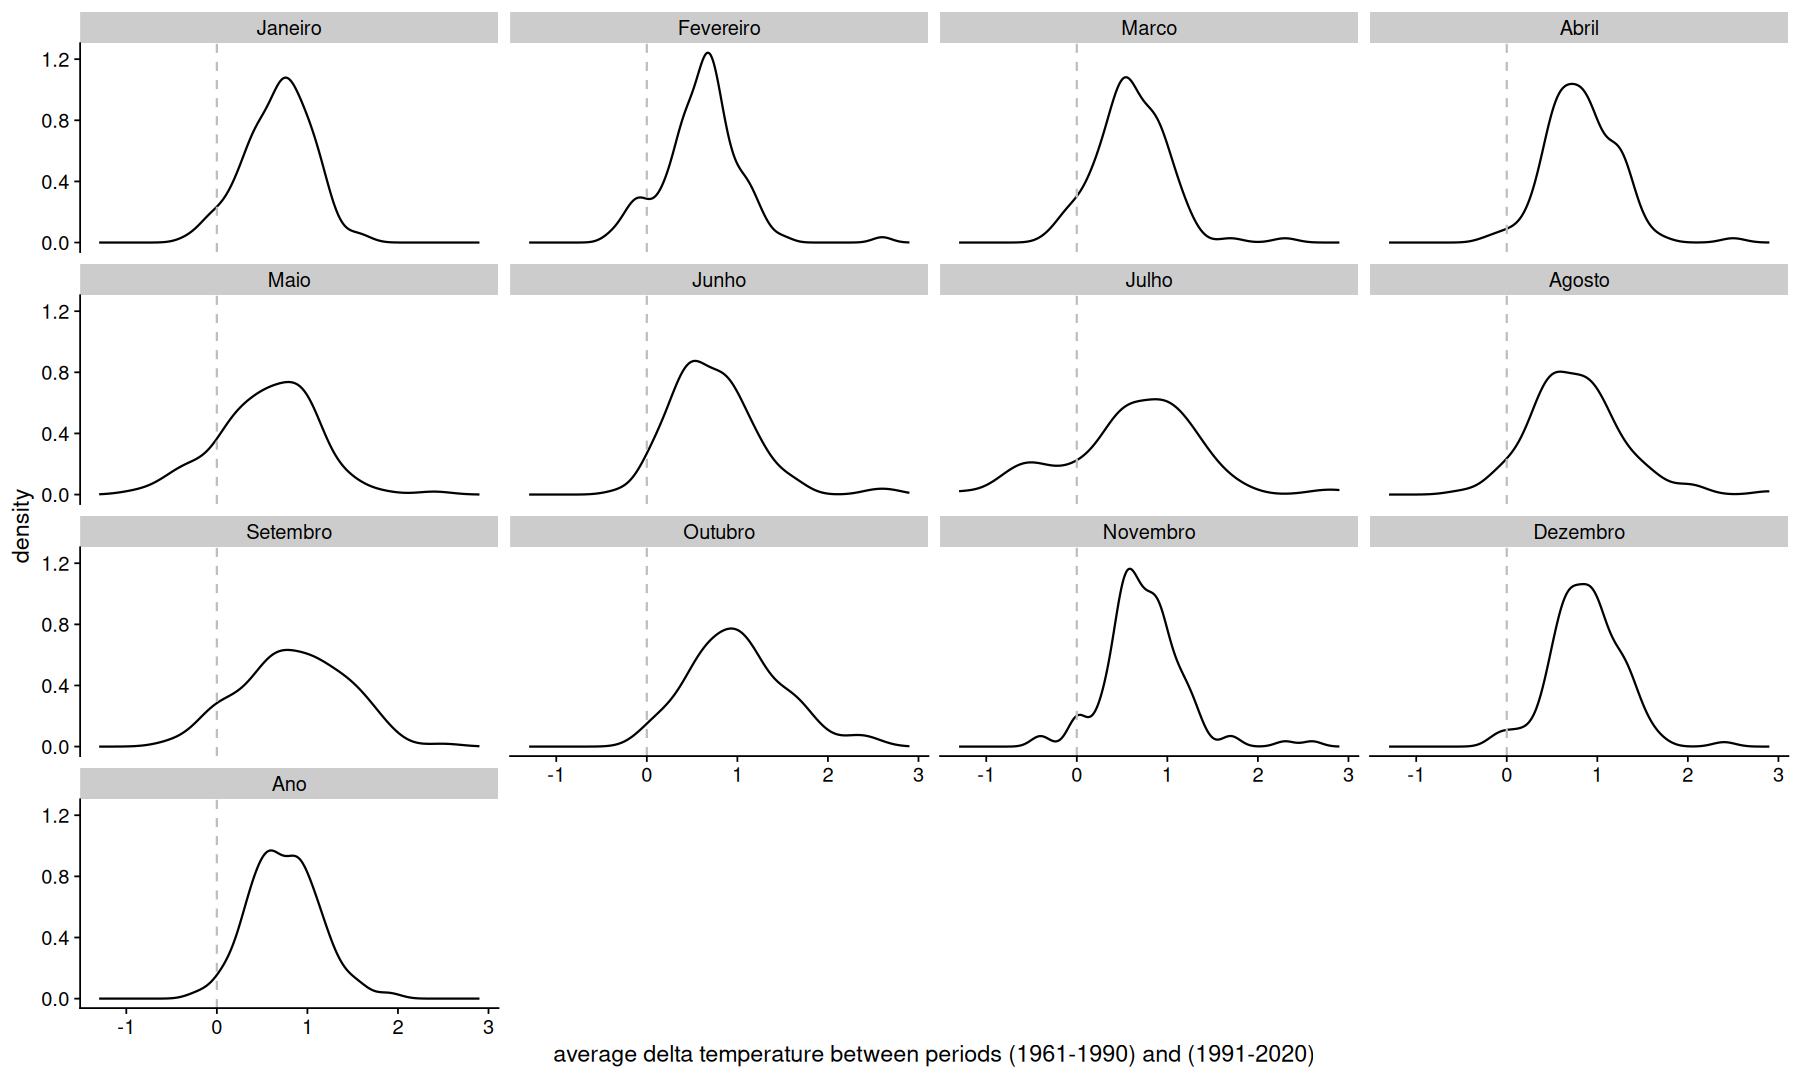

In [22]:
df |>
select(Codigo, mes, temp, periodo) |>
pivot_wider(names_prefix='p', names_from = periodo, values_from = temp) |>
mutate(delta = `p1991-2020` - `p1961-1990`) |>
filter(!is.na(delta)) |>
ggplot(aes(x=delta)) +
geom_density() +
facet_wrap(~mes) +
geom_vline(xintercept=0, linetype=2, color='gray') +
labs(x='average delta temperature between periods (1961-1990) and (1991-2020)')

Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
"collapsing to unique 'x' values"
Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
"collapsing to unique 'x' values"


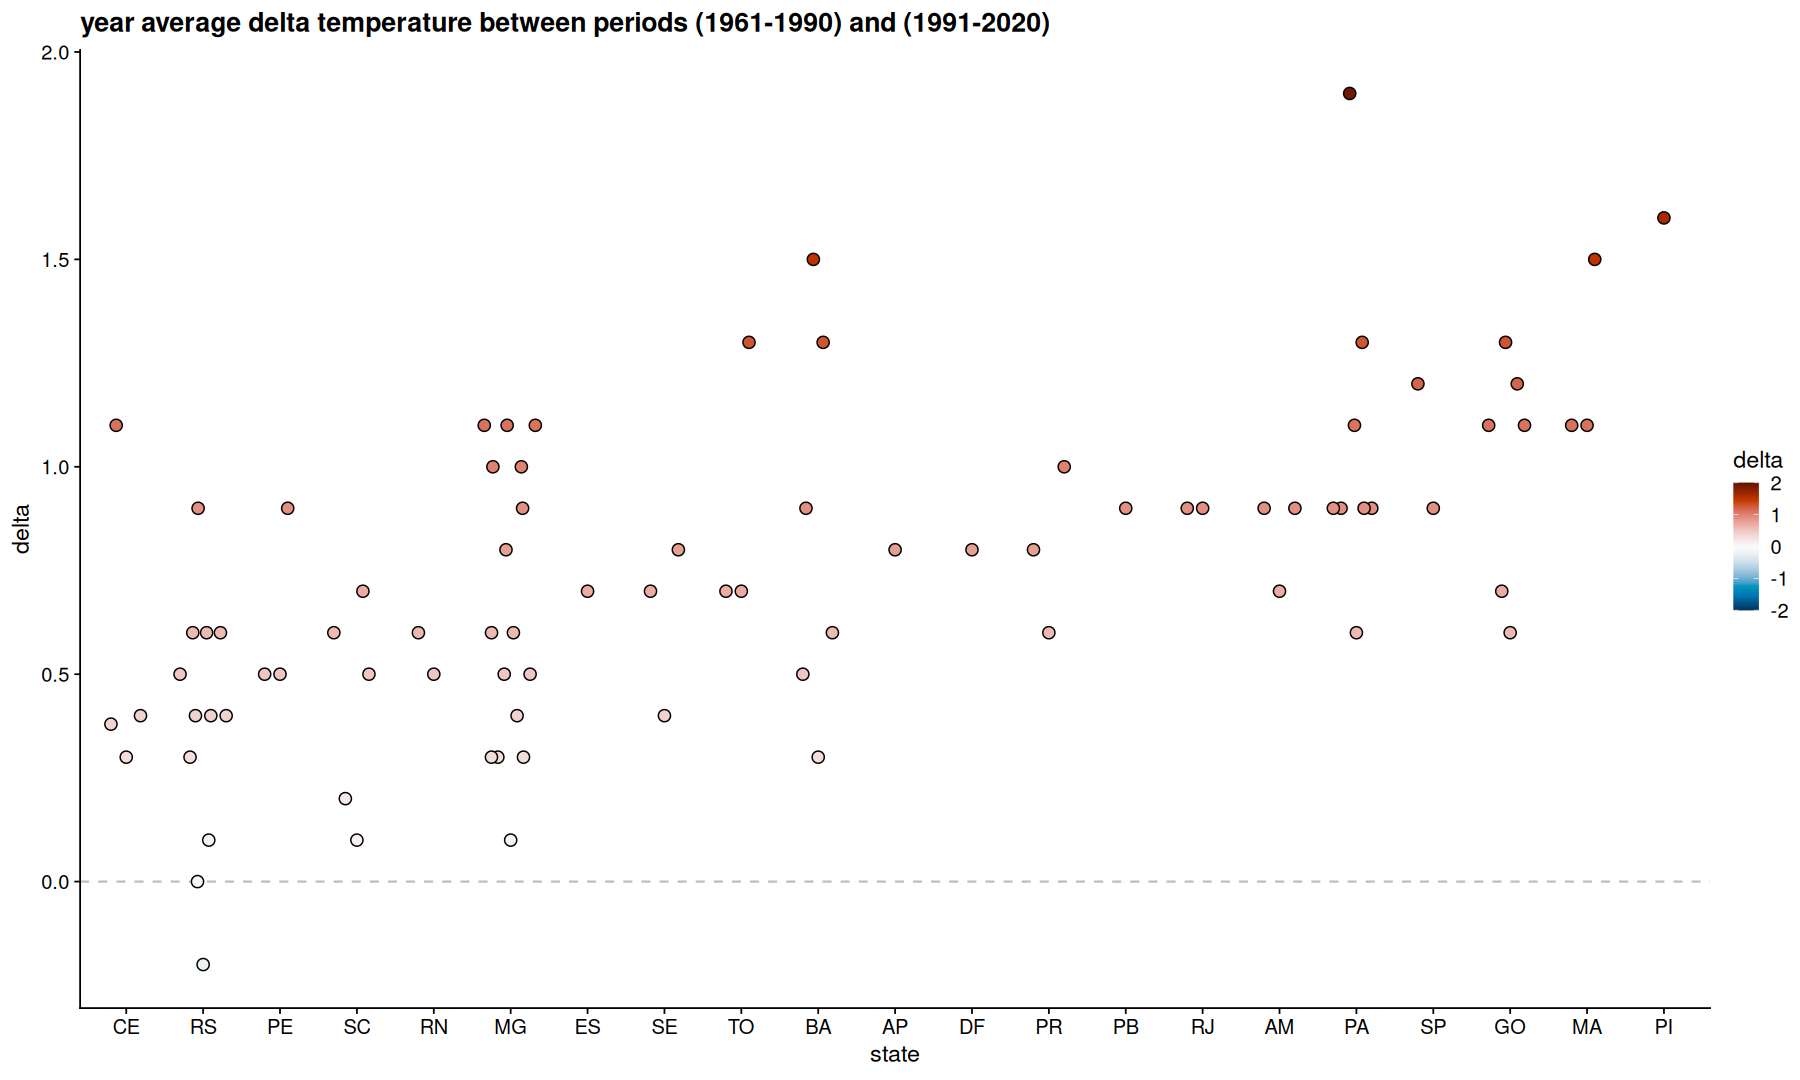

In [23]:
filter(df, mes=='Ano') |>
select(Codigo, temp, UF, periodo) |>
pivot_wider(names_prefix='p', names_from = periodo, values_from = temp) |>
mutate(delta = `p1991-2020` - `p1961-1990`) |>
filter(!is.na(delta)) |>
ggplot(aes(x=fct_reorder(UF,delta), y=delta, fill=delta)) +
scale_fill_paletteer_c(palette='grDevices::RdBu', direction = -1, limits=c(-2, 2), oob=scales::squish) +
geom_hline(yintercept=0, linetype=2, color='gray') +
geom_quasirandom(size=3, shape=21) +
labs(x='state',title='year average delta temperature between periods (1961-1990) and (1991-2020)')